In [48]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["OPENAI_API_KEY"] = os.getenv("AZURE_OPENAI_API_KEY")
os.environ["OPENAI_ENDPOINT"] = os.getenv("AZURE_OPENAI_ENDPOINT")
os.environ["OPENAI_API_VERSION"] = "2024-12-01-preview"
os.environ["OPENAI_DEPLOYMENT_NAME"] = "gpt-4o-mini"
os.environ["OPENAI_MODEL"] = "gpt-4o-mini"
os.environ["LANGSMITH_API_KEY"] = os.getenv("LANGSMITH_API_KEY")
os.environ["LANGSMITH_PROJECT"] = os.getenv("LANGSMITH_PROJECT")
os.environ["LANGSMITH_TRACING_V2"] = os.getenv("LANGSMITH_TRACING_V2")

open_api_key = os.getenv("AZURE_OPENAI_API_KEY")
if open_api_key:
    print(f"Azure Open API Key loaded: {open_api_key[:10]}...{open_api_key[-4:]}")
    print(f"Model: {os.getenv('OPENAI_MODEL')}")
    os.environ["OPENAI_API_KEY"] = open_api_key
else:
    print("Azure API Key not found in environment variables")
    print("Available environment variables with 'Azure':", [k for k in os.environ.keys() if 'Azure' in k.upper()])

groq_api_key = os.getenv("GROQ_API_KEY")
if groq_api_key:
    print(f"GROQ API Key loaded: {groq_api_key[:10]}...{groq_api_key[-4:]}")
    os.environ["GROQ_API_KEY"] = groq_api_key
else:
    print("GROQ API Key not found in environment variables")
    print("Available environment variables with 'GROQ':", [k for k in os.environ.keys() if 'GROQ' in k.upper()])

tavily_api_key = os.getenv("TAVILY_API_KEY")
if tavily_api_key:
    print(f"Tavily API Key loaded: {tavily_api_key[:10]}...{tavily_api_key[-4:]}")
else:
    print("Tavily API Key not found in environment variables")
    print("Available environment variables with 'TAVILY':", [k for k in os.environ.keys() if 'TAVILY' in k.upper()])

langsmith_key = os.getenv("LANGSMITH_API_KEY")
if langsmith_key:
    print(f"Langsmith Key loaded: {langsmith_key[:10]}...{langsmith_key[-4:]}")
    print(f"LANGSMITH_PROJECT: {os.getenv('LANGSMITH_PROJECT')}")
    os.environ["LANGSMITH_API_KEY"] = langsmith_key


Azure Open API Key loaded: 1Sttw3VbMy...EzVq
Model: gpt-4o-mini
GROQ API Key loaded: gsk_kJ3nEw...OOCG
Tavily API Key loaded: tvly-dev-h...xnHL
Langsmith Key loaded: lsv2_pt_41...99ef
LANGSMITH_PROJECT: roadmap-to-ai-ml


In [49]:
from langchain_community.tools import ArxivQueryRun, WikipediaQueryRun
from langchain_community.utilities import ArxivAPIWrapper, WikipediaAPIWrapper
from langchain_core.tools import tool


In [50]:
api_wrapper_arxiv = ArxivAPIWrapper(top_k_results=2, doc_content_chars_max=500)
arxiv = ArxivQueryRun(api_wrapper=api_wrapper_arxiv)
print(arxiv)

api_wrapper=ArxivAPIWrapper(arxiv_search=<class 'arxiv.Search'>, arxiv_exceptions=(<class 'arxiv.ArxivError'>, <class 'arxiv.UnexpectedEmptyPageError'>, <class 'arxiv.HTTPError'>), top_k_results=2, ARXIV_MAX_QUERY_LENGTH=300, continue_on_failure=False, load_max_docs=100, load_all_available_meta=False, doc_content_chars_max=500)


In [51]:
arxiv.invoke("Attention is all you need ")


"Published: 2024-07-22\nTitle: Attention Is All You Need But You Don't Need All Of It For Inference of Large Language Models\nAuthors: Georgy Tyukin, Gbetondji J-S Dovonon, Jean Kaddour, Pasquale Minervini\nSummary: The inference demand for LLMs has skyrocketed in recent months, and serving\nmodels with low latencies remains challenging due to the quadratic input length\ncomplexity of the attention layers. In this work, we investigate the effect of\ndropping MLP and attention layers at inference time o"

In [52]:
api_wrapper_wiki = WikipediaAPIWrapper(top_k_results=2, doc_content_chars_max=500)
wiki = WikipediaQueryRun(api_wrapper=api_wrapper_wiki)
print(wiki)

api_wrapper=WikipediaAPIWrapper(wiki_client=<module 'wikipedia' from '/home/zama/Desktop/code/Roadmap-To-AI-ML/langgraph/venv/lib/python3.12/site-packages/wikipedia/__init__.py'>, top_k_results=2, lang='en', load_all_available_meta=False, doc_content_chars_max=500)


In [53]:
wiki.invoke("what is machine learning?")

'Page: Machine learning\nSummary: Machine learning (ML) is a field of study in artificial intelligence concerned with the development and study of statistical algorithms that can learn from data and generalise to unseen data, and thus perform tasks without explicit instructions. Within a subdiscipline in machine learning, advances in the field of deep learning have allowed neural networks, a class of statistical algorithms, to surpass many previous machine learning approaches in performance.\nML fi'

In [54]:
from langchain_tavily import TavilySearch

tavily = TavilySearch(
    api_key=os.getenv("TAVILY_API_KEY"),
    top_k=2,
    max_results=2,
    max_content_length=500
)
tavily

TavilySearch(max_results=2, api_wrapper=TavilySearchAPIWrapper(tavily_api_key=SecretStr('**********')))

In [55]:
tavily.invoke("What is the latest in AI research?")

{'query': 'What is the latest in AI research?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'title': "What's next for AI in 2025 - MIT Technology Review",
   'url': 'https://www.technologyreview.com/2025/01/08/1109188/whats-next-for-ai-in-2025/',
   'content': 'AI model makers are also keen to pitch their generative products as research tools for scientists. OpenAI let scientists test its latest o1 model and see how it might support them in research.',
   'score': 0.5832277,
   'raw_content': None},
  {'title': 'Artificial Intelligence News -- ScienceDaily',
   'url': 'https://www.sciencedaily.com/news/computers_math/artificial_intelligence/',
   'content': 'Artificial Intelligence News. Everything on AI including futuristic robots with artificial intelligence, computer models of human intelligence and more.',
   'score': 0.41805586,
   'raw_content': None}],
 'response_time': 2.31}

In [56]:
# Custom functions
@tool
def add(a: int, b: int) -> int:
    """Add a and b """
    return a + b

@tool
def subtract(a: int, b: int) -> int:
    """Subtract b from a."""
    return a - b

@tool
def multiply(a: int, b: int) -> int:
    """Multiply two numbers."""
    return a * b

@tool
def divide(a: int, b: int) -> float:
    """Divide a by b."""
    if b == 0:
        raise ValueError("Cannot divide by zero.")
    return a / b

In [70]:
tools = [arxiv, wiki, tavily, add, subtract, multiply, divide]

In [71]:
from langchain_groq import ChatGroq

llm = ChatGroq(
    model="qwen/qwen3-32b",
    api_key=os.getenv("GROQ_API_KEY")
)
llm

ChatGroq(client=<groq.resources.chat.completions.Completions object at 0x7a4f1320b1a0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x7a4f1320d4c0>, model_name='qwen/qwen3-32b', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [59]:
# Test llm call
response = llm.invoke("What is the capital of India?")
response.pretty_print()

================================== Ai Message ==================================

<think>
Okay, so I need to figure out what the capital of India is. Let me start by recalling what I know. I know India is a country in South Asia. The capital is usually the city where the government is based. I've heard the names New Delhi and Delhi before. I think New Delhi is the capital. But wait, isn't Delhi a city? Maybe New Delhi is part of the larger Delhi area.

Wait, I remember that Delhi is a union territory, which is a type of administrative division in India. The capital is part of this union territory. So maybe the capital is New Delhi, which is within the National Capital Territory of Delhi. Let me confirm. I think the government offices, like the Parliament and the President's residence, are in New Delhi. So yes, the capital is New Delhi. But sometimes people refer to Delhi as the capital, which is technically incorrect because it's the National Capital Territory that includes New Delhi. 

In [72]:
llm_with_tools = llm.bind_tools(tools)

In [61]:
from langchain.schema import HumanMessage, SystemMessage, AIMessage

# tavily
response = llm_with_tools.invoke([
    HumanMessage(
        content="What is the recent AI news"
    )
]).tool_calls
response


[{'name': 'tavily_search',
  'args': {'query': 'recent AI news', 'time_range': 'week', 'topic': 'news'},
  'id': 'tvaxd6em5',
  'type': 'tool_call'}]

In [62]:
response = llm_with_tools.invoke([
    HumanMessage(
        content="What gold price in india"
    )
]).tool_calls
response

[{'name': 'tavily_search',
  'args': {'query': 'current gold price in India'},
  'id': 'za581e2rd',
  'type': 'tool_call'}]

In [63]:
#arxiv
response = llm_with_tools.invoke([
    HumanMessage(
        content="Share details on Attention is all you need paper"
    )
]).tool_calls
response

[{'name': 'arxiv',
  'args': {'query': 'Attention is All You Need'},
  'id': 'jda1jpkxv',
  'type': 'tool_call'}]

In [73]:
# State schema
from typing import TypedDict
from langchain_core.messages import AnyMessage
from typing import Annotated
from langgraph.graph.message import add_messages

class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]


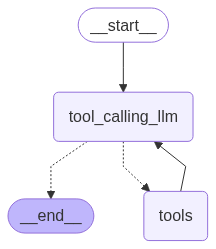

In [78]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

# node
def tool_calling_llm(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

#Build graph
builder = StateGraph(State)

#nodes
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

#edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm", 
    tools_condition,
)
builder.add_edge("tools", "tool_calling_llm")


graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [79]:
# arxiv
messages = graph.invoke(
    {"messages": HumanMessage(content="1706.03762")}
)

for m in messages['messages']:
    m.pretty_print()



================================ Human Message =================================

1706.03762
================================== Ai Message ==================================
Tool Calls:
  arxiv (rskyp5swj)
 Call ID: rskyp5swj
  Args:
    query: 1706.03762
================================= Tool Message =================================
Name: arxiv

Published: 2023-08-02
Title: Attention Is All You Need
Authors: Ashish Vaswani, Noam Shazeer, Niki Parmar, Jakob Uszkoreit, Llion Jones, Aidan N. Gomez, Lukasz Kaiser, Illia Polosukhin
Summary: The dominant sequence transduction models are based on complex recurrent or
convolutional neural networks in an encoder-decoder configuration. The best
performing models also connect the encoder and decoder through an attention
mechanism. We propose a new simple network architecture, the Transformer, base
================================== Ai Message ==================================

The arXiv paper **"Attention Is All You Need"** (arXiv:1706.03762) 

In [80]:
# tavily
messages = graph.invoke(
    {"messages": HumanMessage(content="Share top 10 recent AI news from this month")}
)

for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Share top 10 recent AI news from this month
================================== Ai Message ==================================
Tool Calls:
  tavily_search (8xv4c1xtz)
 Call ID: 8xv4c1xtz
  Args:
    query: top 10 recent AI news this month
    search_depth: advanced
    time_range: month
    topic: general
================================= Tool Message =================================
Name: tavily_search

{"query": "top 10 recent AI news this month", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://medium.com/@CherryZhouTech/ai-news-june-21-27-2025-top-10-ai-breakthroughs-you-missed-344d39a6724a", "title": "AI News | June 21–27, 2025: Top 10 AI Breakthroughs You Missed", "content": "Sign up\n\nSign in\n\nSign up\n\nSign in\n\n# AI News | June 21–27, 2025: Top 10 AI Breakthroughs You Missed\n\n## AI Weekly: YouTube adds AI summaries, ChatGPT hits 30M downloads– are you 

In [81]:
# wiki
messages = graph.invoke(
    {"messages": HumanMessage(content="what is machine learning")}
)

for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

what is machine learning
================================== Ai Message ==================================

Machine learning is a subset of artificial intelligence (AI) that enables systems to learn patterns and make decisions from data without being explicitly programmed for specific tasks. Instead of relying on rigid instructions, machine learning models improve their performance over time by identifying patterns in data through exposure to examples.

Key characteristics:
1. **Data-driven**: Relies on large datasets to train models
2. **Adaptive**: Improves accuracy through experience (more data = better performance)
3. **Generalization**: Can handle new, unseen data after training

Common applications include:
- Image recognition
- Speech processing
- Recommendation systems
- Fraud detection
- Autonomous vehicles

Three main learning types:
1. **Supervised learning** (labeled data)
2. **Unsupervised lea

In [85]:
# Add two numbers
messages = graph.invoke(
    {"messages": HumanMessage(content="what is 2 + 2")}
)

for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

what is 2 + 2
================================== Ai Message ==================================
Tool Calls:
  add (qe9vhdzae)
 Call ID: qe9vhdzae
  Args:
    a: 2
    b: 2
================================= Tool Message =================================
Name: add

4
================================== Ai Message ==================================

The result of 2 + 2 is **4**.


In [84]:
# Add two numbers then multiply by 10
messages = graph.invoke(
    {"messages": HumanMessage(content="First add 2 + 2 then multiply by 10")}
)

for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

First add 2 + 2 then multiply by 10
================================== Ai Message ==================================
Tool Calls:
  add (66dsqd0vb)
 Call ID: 66dsqd0vb
  Args:
    a: 2
    b: 2
  multiply (xz4h7j2j0)
 Call ID: xz4h7j2j0
  Args:
    a: 4
    b: 10
================================= Tool Message =================================
Name: add

4
================================= Tool Message =================================
Name: multiply

40
================================== Ai Message ==================================

The result of adding 2 + 2 is 4. When you multiply that by 10, you get:

**40**
